In [1]:
import time

import torch
from tqdm import tqdm

degrees = 5
epoch = 50000
learning_rate = 1e-2
update_interval = 0.5

# python
class Polynomial(torch.nn.Module):
    def __init__(self, degree):
        super().__init__()
        self.coefficients = torch.nn.Parameter(torch.randn(degree + 1))
        # register as buffer so it's moved with .to() and saved in state_dict, but not optimized
        self.register_buffer('_powers', torch.arange(degree + 1, dtype=self.coefficients.dtype, device=self.coefficients.device))

    def forward(self, x_in: torch.Tensor):
        if x_in.dim() == 1:
            x_powers = x_in.unsqueeze(-1).pow(self._powers)
        elif x_in.dim() == 2 and x_in.shape[1] == self.coefficients.shape[0]:
            x_powers = x_in
        else:
            raise ValueError(f"Input dimension mismatch, got {x_in.shape}, expected {self.coefficients.shape[0]}(xx) or 1(x)")
        return (x_powers * self.coefficients).sum(dim=-1)

    def to_string(self, precision=4, drop_zero=True, with_y=True):
        cof_list = self.coefficients.tolist()
        msg = "y = " if with_y else ""
        is_first = True
        for power, w in enumerate(cof_list):
            if drop_zero and abs(w) < 10 ** (-precision):
                continue

            if is_first:
                msg += f"{w:.{precision}f}"
                is_first = False
            else:
                msg += " - " if w < 0 else " + "
                msg += f"{abs(w):.{precision}f}"

            if power > 1:
                msg += f"x^{power}"
            elif power == 1:
                msg += "x"

        return msg

    def __str__(self):
        return self.to_string()


x = torch.linspace(-3, 3, 2000)
y = torch.sigmoid(x)

model = Polynomial(degrees)

# 其实就是损失函数
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

with tqdm(total=epoch) as pbar:
    p = torch.tensor(range(degrees + 1))
    xx = torch.pow(x.unsqueeze(-1), p)
    update_next = time.time()
    for t in range(epoch):
        # y_pred = model(x)
        y_pred = model(xx)  # much faster, 7000it->9500it

        loss = criterion(y_pred, y)

        pbar.update(1)
        current_time = time.time()
        if current_time > update_next:
            update_next = current_time + update_interval
            pbar.set_postfix(
                loss=loss.item(),
                model=model.to_string(with_y=False)
            )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print(model)

100%|██████████| 50000/50000 [00:05<00:00, 9637.63it/s, loss=0.0382, model=0.5000 + 0.2487x - 0.0143x^3 + 0.0030x^5]                        

y = 0.5000 + 0.2464x - 0.0166x^3 + 0.0007x^5


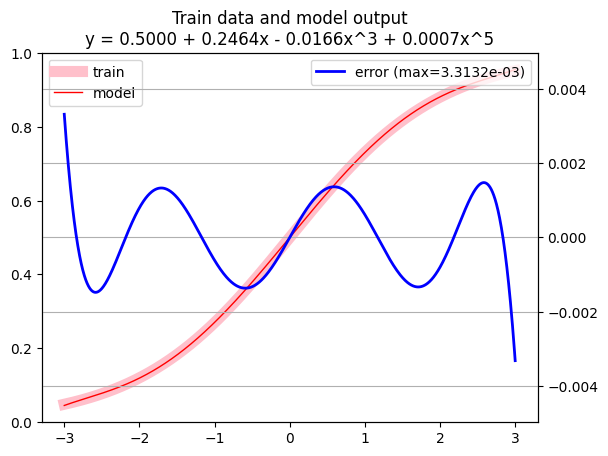

In [2]:
from matplotlib import pyplot as plt

x_plot = x.detach().cpu().numpy()
y_train = y.detach().cpu().numpy()
y_model = model(x).detach().cpu().numpy()

y_error = y_train - y_model
max_error = float(max(abs(y_error)))

plt.figure()

ax1 = plt.subplot()
ax1.plot(x_plot, y_train, linewidth=8, color='pink', label='train')
ax1.plot(x_plot, y_model, linewidth=1, color='red', label='model')
ax1.legend()

ax2 = ax1.twinx()
ax2.plot(x_plot, y_error, linewidth=2, color='blue', label=f'error (max={max_error:.4e})')
ax2.set_ylim(-max_error * 1.5, max_error * 1.5)
ax2.legend()

plt.title(
    f"Train data and model output\n"
    f"{model}"
)
plt.grid(True)
plt.show()

In [3]:
poly = Polynomial(4)

print(poly.to_string())
print(poly.coefficients)
print(poly.coefficients.shape[0])

print(torch.tensor(range(poly.coefficients.shape[0])))

print(poly.forward(torch.tensor([1,2,3,4,5])))

y = 2.3838 + 0.5498x - 1.0666x^2 + 0.6353x^3 - 1.8142x^4
Parameter containing:
tensor([ 2.3838,  0.5498, -1.0666,  0.6353, -1.8142], requires_grad=True)
5
tensor([0, 1, 2, 3, 4])
tensor([ 6.8804e-01, -2.4728e+01, -1.3536e+02, -4.3626e+02, -1.0760e+03],
       grad_fn=<SumBackward1>)
